---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 4**: Embeddings & Semantic Search

### 📅 **Due Date**: Day of Lecture 5, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll build on Homework 3 (BM25 search) by adding **embedding-based semantic search**.

You will:
1. **Generate embeddings** using both local (Hugging Face) and API (OpenAI) models
2. **Implement cosine similarity** from scratch
3. **Implement semantic search** from scratch
4. **Compare BM25 vs semantic search** using Recall
5. **Compare different embedding models** and analyze their differences

**Total Points: 95**

---

## Instructions

- Complete all tasks by filling in code where you see `# YOUR CODE HERE`
- You may use ChatGPT, Claude, documentation, Stack Overflow, etc.
- When using external resources, briefly cite them in a comment
- Run all cells before submitting to ensure they work

**Submission:**
1. Create a branch called `homework-4`
2. Commit and push your work
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Task 1: Environment Setup (10 points)

### 1a. Imports (5 pts)

Import the required libraries and load the WANDS data.

In [1]:
# ruff: noqa: E402

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Import ONLY data loading from helpers
import sys
sys.path.append('../scripts')
from helpers import load_wands_products, load_wands_queries, load_wands_labels

# Embedding libraries - we use these directly
from sentence_transformers import SentenceTransformer
import litellm

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

pd.set_option('display.max_colwidth', 80)
print("All imports successful!")

All imports successful!


In [2]:
# Load the WANDS dataset
products = load_wands_products("data")
queries = load_wands_queries("data")
labels = load_wands_labels("data")

print(f"Products: {len(products):,}")
print(f"Queries: {len(queries):,}")
print(f"Labels: {len(labels):,}")

Products: 42,994
Queries: 480
Labels: 233,448


### 1b. Copy BM25 functions from HW3 (5 pts)

Copy your BM25 implementation from Homework 3. We'll use it to compare against semantic search.

In [3]:
# Copy your BM25 functions from Homework 3

# helpers imports
from helpers import (
    # Data loading
    load_wands_products, load_wands_queries, load_wands_labels,
    # BM25 
    build_index, score_bm25, search_bm25,
    # Evaluation
    evaluate_search,
    # Embeddings
    get_local_model, batch_embed_local,
    # Similarity
    batch_cosine_similarity,
    # Utility
    normalize_scores
)

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()


# Build BM25 index on product names
name_index, name_lengths = build_index(products['product_name'].tolist())
print(f"Index contains {len(name_index):,} unique terms")

Index contains 25,570 unique terms


---

## Task 2: Understanding Embeddings (15 points)

### 2a. Load a local model and generate embeddings (5 pts)

Use `sentence-transformers` to load a local embedding model and generate embeddings for a list of words.

In [4]:
# Load the all-MiniLM-L6-v2 model using SentenceTransformer
# Then generate embeddings for each word in the list
words = ["wooden coffee table", "oak dining table", "red leather sofa", "blue area rug", "kitchen sink"]


# YOUR CODE HERE

# Print the number of embeddings you generated and the dimension of the embeddings

# Load the model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(words)

# Print info about the embeddings
print(f"Number of embeddings: {len(embeddings)}")
print(f"Embedding dimension: {embeddings[0].shape[0]}")



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1599.37it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of embeddings: 5
Embedding dimension: 384


### 2b. Implement cosine similarity and create a similarity matrix (5 pts)

Implement cosine similarity from scratch:

$$\text{cosine\_similarity}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

In [5]:
# Implement cosine similarity from scratch

def cosine_similarity_manual(a, b):
    """Calculate cosine similarity between two vectors."""
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)


# Create similarity matrix

num_items = len(embeddings)
similarity_matrix = np.zeros((num_items, num_items))

for i in range(num_items):
    for j in range(num_items):
        similarity_matrix[i, j] = cosine_similarity_manual(
            embeddings[i], embeddings[j]
        )


# Display as dataframe
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=words,
    columns=words
)

similarity_df

,wooden coffee table,oak dining table,red leather sofa,blue area rug,kitchen sink
wooden coffee table,1.000000,0.588631,0.370622,0.189486,0.295712
oak dining table,0.588631,1.000000,0.337910,0.249521,0.341410
red leather sofa,0.370622,0.337910,1.000000,0.380311,0.057740
blue area rug,0.189486,0.249521,0.380311,1.000000,0.125802
kitchen sink,0.295712,0.341410,0.057740,0.125802,1.000000


### 2c. Embed using OpenAI API (5 pts)

Use `litellm` to get embeddings from OpenAI's API and compare dimensions.

In [6]:
# Use litellm to get an embedding from OpenAI's text-embedding-3-small model


In [7]:
# OpenAI model 
response = litellm.embedding(
    model="text-embedding-3-small",
    input=words
)

openai_embedding = np.array(response.data[0]["embedding"])
print(f"Number of embeddings: {len(embeddings)}")
print("\nOpenAI model (text-embedding-3-small)")
print(f"Dimension: {len(openai_embedding)}")

Number of embeddings: 5

OpenAI model (text-embedding-3-small)
Dimension: 1536


In [8]:
# Cosine similarity for OpenAI embeddings
embeddings = {}
for word in words:
    response = litellm.embedding(model="text-embedding-3-small", input=[word])
    embeddings[word] = np.array(response.data[0]["embedding"])

# Calculate similarity between all pairs using cosine similarity
print("Similarity matrix:")

word_width = max(len(w) for w in words) + 2
header = "".join([f"{'':<{word_width}s}"] + [f"{w:>{word_width}s}" for w in words])
print(header)
print("-" * (word_width + len(words) * word_width))

for w1 in words:
    row = [f"{w1:<{word_width}s}"]
    for w2 in words:
        # Cosine similarity: dot product divided by product of norms
        sim = np.dot(embeddings[w1], embeddings[w2]) / (np.linalg.norm(embeddings[w1]) * np.linalg.norm(embeddings[w2]))
        row.append(f"{sim:>{word_width}.2f}")
    print("".join(row))

Similarity matrix:
                       wooden coffee table     oak dining table     red leather sofa        blue area rug         kitchen sink
------------------------------------------------------------------------------------------------------------------------------
wooden coffee table                   1.00                 0.59                 0.38                 0.31                 0.27
oak dining table                      0.59                 1.00                 0.34                 0.34                 0.34
red leather sofa                      0.38                 0.34                 1.00                 0.42                 0.23
blue area rug                         0.31                 0.34                 0.42                 1.00                 0.28
kitchen sink                          0.27                 0.34                 0.23                 0.28                 1.00


In [9]:
#local model for comparison
model = SentenceTransformer("all-MiniLM-L6-v2")
local_embs = model.encode(words)

print(f"Number of local embeddings: {len(local_embs)}")
print(f"Local embedding dimension: {local_embs[0].shape[0]}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1860.19it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of local embeddings: 5
Local embedding dimension: 384


In [10]:
# Compare the dimension with the local model

## OpenAI model has a lot more dimensions (1536) compared to the local model which only has 384
## The similarity matrixes are different for different word combinations

---

## Task 3: Batch Embedding Products (20 points)

### 3a. Embed a product sample (10 pts)

Create a combined text field and embed 5,000 products using the local model.

In [11]:
# Get a consistent sample


In [12]:
# Create a combined text field (product_name + product_class)
# Then embed all products using model.encode()

# YOUR CODE HERE

In [13]:
# Get consistent sample
products_sample = products.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Working with {len(products_sample):,} products")
products_sample[['product_id', 'product_name', 'product_class']].head()


# Create a combined text field (product_name + product_class)
products_sample['embed_text'] = (
    products_sample['product_name'].fillna('') + ' ' +
    products_sample['product_class'].fillna('')
)

products_sample['embed_text'].head()


# Then embed all products using model.encode()
print("Embedding products...")
start = time.time()
product_embeddings = model.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

print(f"Done in {time.time() - start:.1f}s")
print(f"Embeddings shape: {product_embeddings.shape}")



Working with 5,000 products
Embedding products...


Batches: 100%|██████████| 157/157 [00:04<00:00, 37.24it/s]

Done in 4.3s
Embeddings shape: (5000, 384)


### 3b. Save and load embeddings (5 pts)

Save embeddings to a `.npy` file so you don't have to recompute them.

In [14]:
# Save embeddings to ../temp/hw4_embeddings.npy
# Save products_sample to ../temp/hw4_products.csv
# Then load them back and verify they match

In [15]:
# Save embeddings to ../temp/hw4_embeddings.npy
# Save products_sample to ../temp/hw4_products.csv

from pathlib import Path


# Define paths
temp_dir = Path("../temp")
temp_dir.mkdir(parents=True, exist_ok=True)

np.save(temp_dir / "hw4_embeddings.npy", product_embeddings)
products_sample.to_csv(temp_dir / "hw4_products.csv", index=False)



In [16]:
# Then load them back and verify they match

In [17]:
# Load embeddings back
print("\nLoading embeddings back...")
loaded_embeddings = np.load(temp_dir / "hw4_embeddings.npy")
print(f"  Loaded embeddings shape: {loaded_embeddings.shape}")

# Load products back
print("\nLoading products back...")
loaded_products = pd.read_csv(temp_dir / "hw4_products.csv")
print(f"  Loaded products shape: {loaded_products.shape}")


Loading embeddings back...
  Loaded embeddings shape: (5000, 384)

Loading products back...
  Loaded products shape: (5000, 10)


In [18]:
# Then load them back and verify they match

# Verify embeddings match
print("\nVerifying embeddings match...")
embeddings_match = np.allclose(product_embeddings, loaded_embeddings)
print(f"  Embeddings match: {embeddings_match}")
if embeddings_match:
    print("  ✓ Embeddings are identical!")
else:
    print("  ✗ Embeddings differ!")
    max_diff = np.abs(product_embeddings - loaded_embeddings).max()
    print(f"  Maximum difference: {max_diff}")


# Verify products match
print("\nVerifying products match...")
# Reset index to ensure comparison works
products_sample_reset = products_sample.reset_index(drop=True)
loaded_products_reset = loaded_products.reset_index(drop=True)
products_match = products_sample_reset.equals(loaded_products_reset)
print(f"  Products match: {products_match}")
if products_match:
    print("  ✓ Products DataFrame is identical!")
else:
    print("  ✗ Products DataFrame differs!")
    # Check which columns differ
    for col in products_sample_reset.columns:
        if not products_sample_reset[col].equals(loaded_products_reset[col]):
            print(f"    Column '{col}' differs")



Verifying embeddings match...
  Embeddings match: True
  ✓ Embeddings are identical!

Verifying products match...
  Products match: True
  ✓ Products DataFrame is identical!


### 3c. Cost estimation (5 pts)

Estimate the cost to embed all 43K products using OpenAI's API.

**Pricing**: text-embedding-3-small costs ~$0.02 per 1 million tokens.

In [19]:
# Use tiktoken to count actual tokens in the sample
# Then extrapolate to estimate cost for the full dataset

In [20]:

import tiktoken

# Get the encoding for text-embedding-3-small (uses cl100k_base)
encoding = tiktoken.get_encoding("cl100k_base")

# Count tokens for each product in the sample
print("Counting tokens in sample...")
sample_token_counts = []
for text in products_sample['embed_text']:
    tokens = encoding.encode(str(text))
    sample_token_counts.append(len(tokens))

sample_token_counts = np.array(sample_token_counts)

# Calculate statistics
total_sample_tokens = sample_token_counts.sum()
mean_tokens_per_product = sample_token_counts.mean()
median_tokens_per_product = np.median(sample_token_counts)

print(f"\nToken count statistics for sample ({len(products_sample):,} products):")
print(f"  Total tokens: {total_sample_tokens:,}")
print(f"  Mean tokens per product: {mean_tokens_per_product:.1f}")
print(f"  Median tokens per product: {median_tokens_per_product:.1f}")
print(f"  Min tokens: {sample_token_counts.min()}")
print(f"  Max tokens: {sample_token_counts.max()}")

# Calculate cost for sample
# Pricing: $0.02 per 1 million tokens
cost_per_million_tokens = 0.02
sample_cost = (total_sample_tokens / 1_000_000) * cost_per_million_tokens

print(f"\nCost for sample ({len(products_sample):,} products):")
print(f"  Total tokens: {total_sample_tokens:,}")
print(f"  Cost: ${sample_cost:.4f}")

# Extrapolate to full dataset
total_products = len(products)
estimated_total_tokens = mean_tokens_per_product * total_products
estimated_total_cost = (estimated_total_tokens / 1_000_000) * cost_per_million_tokens

print(f"\n{'='*60}")
print(f"COST ESTIMATION FOR FULL DATASET")
print(f"{'='*60}")
print(f"Total products in dataset: {total_products:,}")
print(f"Estimated total tokens: {estimated_total_tokens:,.0f}")
print(f"Estimated cost: ${estimated_total_cost:.4f}")
print(f"\nNote: This is an estimate based on the sample's average tokens per product.")
print(f"Actual cost may vary slightly depending on the distribution of text lengths.")


#code provided with the help of cursor

Counting tokens in sample...

Token count statistics for sample (5,000 products):
  Total tokens: 65,077
  Mean tokens per product: 13.0
  Median tokens per product: 12.0
  Min tokens: 3
  Max tokens: 68

Cost for sample (5,000 products):
  Total tokens: 65,077
  Cost: $0.0013

COST ESTIMATION FOR FULL DATASET
Total products in dataset: 42,994
Estimated total tokens: 559,584
Estimated cost: $0.0112

Note: This is an estimate based on the sample's average tokens per product.
Actual cost may vary slightly depending on the distribution of text lengths.


---

## Task 4: Semantic Search (25 points)

### 4a. Implement semantic search (15 pts)

Implement a semantic search function from scratch.

In [21]:
# Implement batch cosine similarity for efficiency
# Implement semantic search




In [22]:
def semantic_search_local(query, product_embeddings, products_df, k=10):
    """Search products using local embedding similarity."""
    # 1. Embed the query
    model = get_local_model("all-MiniLM-L6-v2")
    query_emb = model.encode(query, convert_to_numpy=True)
    
    # 2. Calculate similarity to all products
    similarities = batch_cosine_similarity(query_emb, product_embeddings)
    
    # 3. Get top-k indices
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Build results DataFrame
    results = products_df.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results

In [23]:
# Test semantic search


In [24]:
# Test semantic search!
results = semantic_search_local("couch", product_embeddings, products_sample)
results[['rank', 'product_name', 'product_class', 'similarity']]

Loading model 'all-MiniLM-L6-v2' from Hugging Face...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2059.80it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded! Embedding dimension: 384


,rank,product_name,product_class,similarity
723,1,sofa bed with ottoman,NaN,0.619436
4532,2,"convertible sectional sofa couch , l-shaped couch with modern linen fabric f...",Sectionals,0.596127
4056,3,novogratz brittany 81.5 '' round arm sleeper,Sofas,0.594750
3032,4,simge patio sofa with cushions,Patio Sofas,0.592612
1945,5,bailey 79.5 '' velvet recessed arm sofa,Sofas,0.582845
4768,6,castilloux patio sofa with cushions,Patio Sofas,0.581542
1947,7,garren 52.4 '' square arm loveseat,Sofas,0.578263
2809,8,weinman 91 '' chenille charles of london sofa,Sofas,0.578170
2120,9,kendall sectional sofa with ottoman,Sectionals,0.577216
2676,10,connie 58 '' vegan leather square arm loveseat,Reception Sofas & Loveseats|Sofas,0.577189


### 4b. Evaluate and compare BM25 vs semantic search (10 pts)

Implement Recall@k and compare the two search methods.

In [25]:
# Implement Recall@k


In [26]:
# Implement Recall@k

# Search for "sofa" with semantic search, k = 10
sem_results = semantic_search_local("sofa", product_embeddings, products_sample, k=10)
print("Semantic for 'sofa':")
print(sem_results[['product_name', 'similarity']].to_string())

Semantic for 'sofa':
                                       product_name  similarity
723                           sofa bed with ottoman    0.752683
2809  weinman 91 '' chenille charles of london sofa    0.744874
2120            kendall sectional sofa with ottoman    0.735309
3371            samuel 91 '' velvet flared arm sofa    0.734664
3032                 simge patio sofa with cushions    0.728014
1945        bailey 79.5 '' velvet recessed arm sofa    0.727764
4330           watonga 53.15 '' square arm sofa bed    0.717769
611               arshleen patio sofa with cushions    0.716133
4335                araceli 65.5 '' square arm sofa    0.714181
1947             garren 52.4 '' square arm loveseat    0.707218


In [27]:
# Build BM25 index for comparison



In [28]:
# Build BM25 index for the sample
sample_index, sample_lengths = build_index(products_sample['product_name'].tolist())

# Search for "sofa" with BM25
bm25_results = search_bm25("sofa", sample_index, products_sample, sample_lengths, k=10)
print("BM25 for 'sofa':")
print(bm25_results[['product_name', 'bm25_score']].to_string())

print("\n" + "="*60 + "\n")


BM25 for 'sofa':
                           product_name  bm25_score
4769                anibella patio sofa    4.869611
2993                lenville patio sofa    4.869611
3296           chaise lounge floor sofa    4.509064
723               sofa bed with ottoman    4.509064
2297             47 '' armless sofa bed    4.509064
239        vanetten industrial dog sofa    4.509064
4046   chafin contemporary leather sofa    4.509064
4523     kaing patio sofa with cushions    4.198227
2301  hakon twin 70 '' convertible sofa    4.198227
611   arshleen patio sofa with cushions    4.198227




In [29]:
# Filter queries to those with products in our sample


In [30]:
# Filter queries to those with products in our sample
sample_product_ids = set(products_sample['product_id'])
sample_labels = labels[labels['product_id'].isin(sample_product_ids)]
sample_query_ids = set(sample_labels['query_id'])
sample_queries = queries[queries['query_id'].isin(sample_query_ids)]

print(f"Queries with products in sample: {len(sample_queries)}")

Queries with products in sample: 473


In [31]:
# Evaluate both BM25 and semantic search on all queries
# Calculate Recall@10 for each method

In [32]:
# Evaluate BM25 on sample
print("Evaluating BM25...")
bm25_eval = evaluate_search(
    lambda q: search_bm25(q, sample_index, products_sample, sample_lengths, k=10),
    sample_queries, sample_labels, k=10
)

Evaluating BM25...
Evaluated 473 queries
Mean Recall@10: 0.3569


In [33]:
# Evaluate Semantic Search on sample
print("Evaluating Semantic Search...")
semantic_eval = evaluate_search(
    lambda q: semantic_search_local(q, product_embeddings, products_sample, k=10),
    sample_queries, sample_labels, k=10
)

Evaluating Semantic Search...
Evaluated 473 queries
Mean Recall@10: 0.3253


In [34]:
# Compare!
print("\n" + "="*40)
print("COMPARISON")
print("="*40)
print(f"BM25 Mean Recall@10:     {bm25_eval['recall'].mean():.4f}")
print(f"Semantic Mean Recall@10: {semantic_eval['recall'].mean():.4f}")

# Combine evaluations
comparison = bm25_eval.merge(semantic_eval, on=['query_id', 'query'], suffixes=('_bm25', '_semantic'))
comparison['diff'] = comparison['recall_semantic'] - comparison['recall_bm25']

print(f"Semantic wins: {(comparison['diff'] > 0).sum()} queries")
print(f"BM25 wins: {(comparison['diff'] < 0).sum()} queries")
print(f"Tie: {(comparison['diff'] == 0).sum()} queries")


COMPARISON
BM25 Mean Recall@10:     0.3569
Semantic Mean Recall@10: 0.3253
Semantic wins: 118 queries
BM25 wins: 173 queries
Tie: 182 queries


In [35]:
# Queries where BM25 wins big
print("Queries where BM25 wins:")
bm25_wins = comparison.nsmallest(5, 'diff')
bm25_wins[['query', 'recall_bm25', 'recall_semantic', 'diff']]

Queries where BM25 wins:


,query,recall_bm25,recall_semantic,diff
374,mom urn,1.000000,0.000000,-1.000000
462,rattan truck,1.000000,0.000000,-1.000000
306,malachi sled,1.000000,0.285714,-0.714286
355,croscill ashton,1.000000,0.285714,-0.714286
327,itchington butterfly,0.857143,0.142857,-0.714286


In [36]:
# Queries where semantic search wins big
print("Queries where SEMANTIC wins:")
semantic_wins = comparison.nlargest(5, 'diff')
semantic_wins[['query', 'recall_bm25', 'recall_semantic', 'diff']]

Queries where SEMANTIC wins:


,query,recall_bm25,recall_semantic,diff
467,48 inch kitchen hood,0.000000,0.909091,0.909091
356,gas detector,0.250000,1.000000,0.750000
373,dining table vinyl cloth,0.000000,0.600000,0.600000
282,round outdoor patio cover,0.230769,0.769231,0.538462
45,beach blue headboard,0.000000,0.454545,0.454545


In [37]:
# Visualize comparison


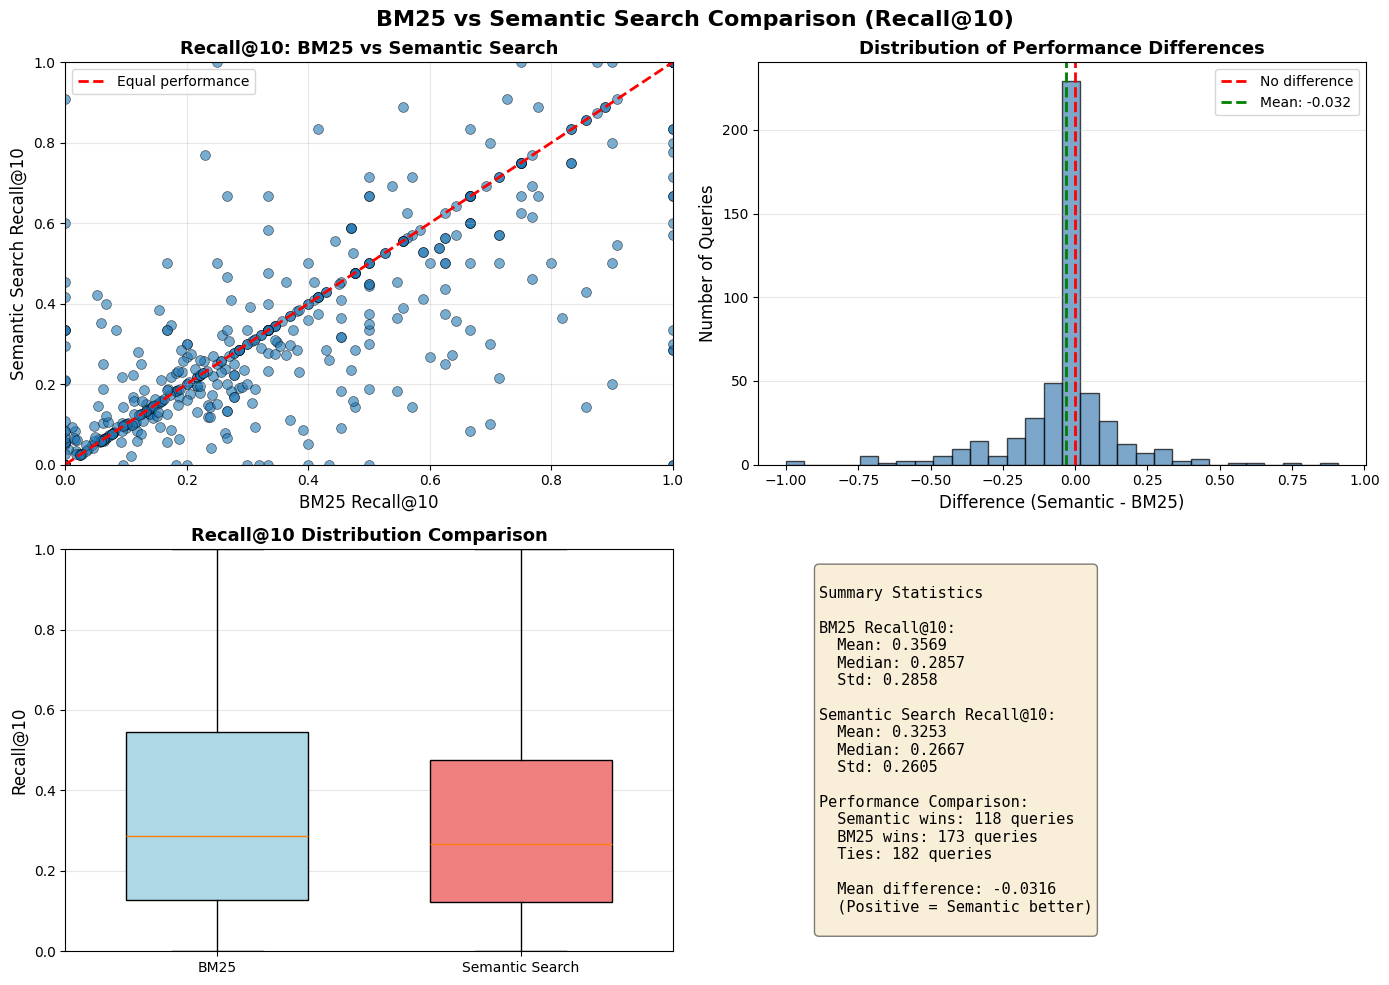


KEY INSIGHTS:
Overall, Semantic Search has lower average recall
  BM25 mean recall: 0.3569
  Semantic mean recall: 0.3253
  Difference: -0.0316


In [38]:

# Create a comprehensive visualization comparing BM25 vs Semantic Search

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BM25 vs Semantic Search Comparison (Recall@10)', fontsize=16, fontweight='bold')

# 1. Scatter plot: BM25 Recall vs Semantic Recall
ax1 = axes[0, 0]
ax1.scatter(comparison['recall_bm25'], comparison['recall_semantic'], 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Equal performance')
ax1.set_xlabel('BM25 Recall@10', fontsize=12)
ax1.set_ylabel('Semantic Search Recall@10', fontsize=12)
ax1.set_title('Recall@10: BM25 vs Semantic Search', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# 2. Histogram of differences
ax2 = axes[0, 1]
ax2.hist(comparison['diff'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
ax2.axvline(x=comparison['diff'].mean(), color='green', linestyle='--', 
           linewidth=2, label=f'Mean: {comparison["diff"].mean():.3f}')
ax2.set_xlabel('Difference (Semantic - BM25)', fontsize=12)
ax2.set_ylabel('Number of Queries', fontsize=12)
ax2.set_title('Distribution of Performance Differences', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Box plot comparing the two methods
ax3 = axes[1, 0]
box_data = [comparison['recall_bm25'], comparison['recall_semantic']]
bp = ax3.boxplot(box_data, labels=['BM25', 'Semantic Search'], 
                patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax3.set_ylabel('Recall@10', fontsize=12)
ax3.set_title('Recall@10 Distribution Comparison', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 1)

# 4. Summary statistics
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = f"""
Summary Statistics

BM25 Recall@10:
  Mean: {comparison['recall_bm25'].mean():.4f}
  Median: {comparison['recall_bm25'].median():.4f}
  Std: {comparison['recall_bm25'].std():.4f}

Semantic Search Recall@10:
  Mean: {comparison['recall_semantic'].mean():.4f}
  Median: {comparison['recall_semantic'].median():.4f}
  Std: {comparison['recall_semantic'].std():.4f}

Performance Comparison:
  Semantic wins: {(comparison['diff'] > 0).sum()} queries
  BM25 wins: {(comparison['diff'] < 0).sum()} queries
  Ties: {(comparison['diff'] == 0).sum()} queries
  
  Mean difference: {comparison['diff'].mean():.4f}
  (Positive = Semantic better)
"""
ax4.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print additional insights
print(f"\n{'='*60}")
print("KEY INSIGHTS:")
print(f"{'='*60}")
print(f"Overall, Semantic Search has {'higher' if comparison['recall_semantic'].mean() > comparison['recall_bm25'].mean() else 'lower'} average recall")
print(f"  BM25 mean recall: {comparison['recall_bm25'].mean():.4f}")
print(f"  Semantic mean recall: {comparison['recall_semantic'].mean():.4f}")
print(f"  Difference: {comparison['diff'].mean():.4f}")

#Code provided by cursor and chatgpt

---

## Task 5: Compare Embedding Models (20 points)

### 5a. Embed products with two different models (10 pts)

Compare embeddings from:
- `BAAI/bge-base-en-v1.5`
- `sentence-transformers/all-mpnet-base-v2`

In [39]:
# Load the two embedding models

In [40]:
# Load the models
bge_model = SentenceTransformer("BAAI/bge-base-en-v1.5")
mpnet_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1418.28it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1294.98it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
# Embed products with both models


In [42]:
# Use product sample from before
#print(f"Working with {len(products_sample):,} products")
#products_sample[['product_id', 'product_name', 'product_class']].head()


# Create a combined text field (product_name + product_class)
#products_sample['embed_text'] = (
#    products_sample['product_name'].fillna('') + ' ' +
#    products_sample['product_class'].fillna('')
#)

#products_sample['embed_text'].head()


In [43]:

# Generate embeddings
embeddings_bge = bge_model.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)
embeddings_mpnet = mpnet_model.encode(products_sample['embed_text'].tolist(), show_progress_bar=True)

print(f"Embeddings shape: {embeddings_bge.shape}")
print(f"Embeddings shape: {embeddings_mpnet.shape}")

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches: 100%|██████████| 157/157 [00:23<00:00,  6.71it/s]

Embeddings shape: (5000, 768)
Embeddings shape: (5000, 768)


In [44]:
test_queries = [
    "comfortable sofa",
    "star wars rug",
    "modern coffee table",
    "minimalist desk",
    "kids bedroom decor",
    "luxury leather couch",
    "round dining table",
]

#query embeddings
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

query_embeddings_bge = bge_model.encode(
    test_queries, normalize_embeddings=True
)

query_embeddings_mpnet = mpnet_model.encode(
    test_queries, normalize_embeddings=True
)



#implement search
def semantic_search_local(query, model, product_embeddings, products_df, k=10):
    """Search products using local embedding similarity."""
    
    # 1. Embed the query
    query_emb = model.encode(query, convert_to_numpy=True, normalize_embeddings=True)
    
    # 2. Calculate similarity to all products
    similarities = batch_cosine_similarity(query_emb, product_embeddings)
    
    # 3. Get top-k indices
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Build results DataFrame
    results = products_df.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results



for q in test_queries:
    print(f"\n🔍 Query: {q}")

    print("\nBGE results:")
    display(
        semantic_search_local(q, bge_model, embeddings_bge, products_sample)
        [['rank', 'product_name', 'product_class', 'similarity']]
    )

    print("\nMPNet results:")
    display(
        semantic_search_local(q, mpnet_model, embeddings_mpnet, products_sample)
        [['rank', 'product_name', 'product_class', 'similarity']]
    )

    


🔍 Query: comfortable sofa

BGE results:


,rank,product_name,product_class,similarity
2736,1,baeten patio sofa with cushions,NaN,0.808782
4741,2,94 '' square arm sofa with reversible cushions,NaN,0.804717
4800,3,mccaffery 74 '' round arm sofa,NaN,0.800535
723,4,sofa bed with ottoman,NaN,0.798662
865,5,86 '' rolled arm sofa with reversible cushions,NaN,0.797221
2771,6,wimberley 76 '' pillow top arm reclining sofa,Sofas,0.796777
1501,7,alliser 87 '' square arm reclining sofa,Sofas,0.793133
2120,8,kendall sectional sofa with ottoman,Sectionals,0.791797
2418,9,eddison 90 '' rolled arm reclining sofa,Sofas,0.791180
147,10,phokas 93 '' square arm sofa,NaN,0.786649



MPNet results:


,rank,product_name,product_class,similarity
611,1,arshleen patio sofa with cushions,Patio Sofas,0.747832
964,2,aidann patio sectional with cushions,Patio Sofas,0.747359
250,3,lucey patio sectional with cushions,Patio Sofas,0.735516
147,4,phokas 93 '' square arm sofa,NaN,0.726604
1668,5,abrish patio sectional with cushions,Patio Sofas,0.725498
4722,6,honeycutt patio sofa with cushions,Patio Sofas,0.721715
835,7,mireya patio sectional with cushions,Patio Sofas,0.721093
2410,8,noor 74 '' wide patio sofa with cushions,Patio Sofas,0.720920
2283,9,botond patio sectional with cushions,Patio Sofas,0.720140
4768,10,castilloux patio sofa with cushions,Patio Sofas,0.717094



🔍 Query: star wars rug

BGE results:


...

,rank,product_name,product_class,similarity
4066,1,chafin series leather loveseat,Reception Sofas & Loveseats|Sofas,0.736732
4046,2,chafin contemporary leather sofa,Reception Sofas & Loveseats|Sofas,0.722010
2414,3,leather upholstered dining chair,Dining Chairs,0.715674
2408,4,adcock faux leather right hand facing sofa & chaise with ottoman,Sectionals,0.702114
1755,5,leather queen anne back arm chair in dark brown,Dining Chairs,0.689563
3313,6,berchmans synthetic leather upholstered dining chair,Dining Chairs,0.688639
979,7,mondawe tufted velvet side chair,NaN,0.688149
3371,8,samuel 91 '' velvet flared arm sofa,Sofas,0.684778
50,9,marbleton 68 '' faux leather flared arm loveseat,Sofas,0.684425
1697,10,umer 66.9 '' faux leather tuxedo arm loveseat,Sofas,0.682352



🔍 Query: round dining table

BGE results:


,rank,product_name,product_class,similarity
3593,1,annie dining table,Dining Tables,0.787233
4851,2,ivonne dining table,Dining Tables,0.781805
23,3,orland dining table,Dining Tables,0.775554
507,4,welliver dining table,Dining Tables,0.775456
2069,5,yarbro dining table,Dining Tables,0.772388
4908,6,mohr dot dining table,Dining Tables,0.769638
1338,7,conall dining table,Dining Tables,0.767016
4270,8,mayton dining table,Dining Tables,0.766493
827,9,overstreet rustic pub table,Dining Tables,0.764459
2880,10,braylen dining table,Dining Tables,0.763828



MPNet results:


,rank,product_name,product_class,similarity
109,1,theobald dining table,Dining Tables,0.795481
1338,2,conall dining table,Dining Tables,0.767842
2880,3,braylen dining table,Dining Tables,0.722064
3883,4,card dining table,Dining Tables,0.718038
4851,5,ivonne dining table,Dining Tables,0.701129
1286,6,hill country balcones friendship dining table,Dining Tables,0.697699
827,7,overstreet rustic pub table,Dining Tables,0.694880
825,8,poirier dining table,Dining Tables,0.689409
4469,9,frankie dining table,Dining Tables,0.687980
1279,10,bales dining table,Dining Tables,0.684234


In [45]:
test_queries = [
    "comfortable sofa",
    "modern couch",
    "leather sectional",
    "small apartment sofa",
    "luxury living room furniture"
]



### 5b. Compare search results between models (10 pts)

Evaluate both models on the same queries and analyze differences.

In [46]:
# Compare results for specific queries
test_queries = ["comfortable sofa", "star wars rug", "modern coffee table"]
# add more!

In [47]:
test_queries = [
    "comfortable sofa",
    "star wars rug",
    "modern coffee table",
    "minimalist desk",
    "kids bedroom decor",
    "luxury leather couch",
    "round dining table",
]

#query embeddings
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

query_embeddings_bge = bge_model.encode(
    test_queries, normalize_embeddings=True
)

query_embeddings_mpnet = mpnet_model.encode(
    test_queries, normalize_embeddings=True
)


#implement search
def semantic_search_local(query, model, product_embeddings, products_df, k=10):
    """Search products using local embedding similarity."""
    
    # 1. Embed the query
    query_emb = model.encode(query, convert_to_numpy=True, normalize_embeddings=True)
    
    # 2. Calculate similarity to all products
    similarities = batch_cosine_similarity(query_emb, product_embeddings)
    
    # 3. Get top-k indices
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Build results DataFrame
    results = products_df.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results



for q in test_queries:
    print(f"\n🔍 Query: {q}")

    print("\nBGE results:")
    display(
        semantic_search_local(q, bge_model, embeddings_bge, products_sample)
        [['rank', 'product_name', 'product_class', 'similarity']]
    )

    print("\nMPNet results:")
    display(
        semantic_search_local(q, mpnet_model, embeddings_mpnet, products_sample)
        [['rank', 'product_name', 'product_class', 'similarity']]
    )


#code assisted by chatgpt


🔍 Query: comfortable sofa

BGE results:


,rank,product_name,product_class,similarity
2736,1,baeten patio sofa with cushions,NaN,0.808782
4741,2,94 '' square arm sofa with reversible cushions,NaN,0.804717
4800,3,mccaffery 74 '' round arm sofa,NaN,0.800535
723,4,sofa bed with ottoman,NaN,0.798662
865,5,86 '' rolled arm sofa with reversible cushions,NaN,0.797221
2771,6,wimberley 76 '' pillow top arm reclining sofa,Sofas,0.796777
1501,7,alliser 87 '' square arm reclining sofa,Sofas,0.793133
2120,8,kendall sectional sofa with ottoman,Sectionals,0.791797
2418,9,eddison 90 '' rolled arm reclining sofa,Sofas,0.791180
147,10,phokas 93 '' square arm sofa,NaN,0.786649



MPNet results:


,rank,product_name,product_class,similarity
611,1,arshleen patio sofa with cushions,Patio Sofas,0.747832
964,2,aidann patio sectional with cushions,Patio Sofas,0.747359
250,3,lucey patio sectional with cushions,Patio Sofas,0.735516
147,4,phokas 93 '' square arm sofa,NaN,0.726604
1668,5,abrish patio sectional with cushions,Patio Sofas,0.725498
4722,6,honeycutt patio sofa with cushions,Patio Sofas,0.721715
835,7,mireya patio sectional with cushions,Patio Sofas,0.721093
2410,8,noor 74 '' wide patio sofa with cushions,Patio Sofas,0.720920
2283,9,botond patio sectional with cushions,Patio Sofas,0.720140
4768,10,castilloux patio sofa with cushions,Patio Sofas,0.717094



🔍 Query: star wars rug

BGE results:


...

,rank,product_name,product_class,similarity
4066,1,chafin series leather loveseat,Reception Sofas & Loveseats|Sofas,0.736732
4046,2,chafin contemporary leather sofa,Reception Sofas & Loveseats|Sofas,0.722010
2414,3,leather upholstered dining chair,Dining Chairs,0.715674
2408,4,adcock faux leather right hand facing sofa & chaise with ottoman,Sectionals,0.702114
1755,5,leather queen anne back arm chair in dark brown,Dining Chairs,0.689563
3313,6,berchmans synthetic leather upholstered dining chair,Dining Chairs,0.688639
979,7,mondawe tufted velvet side chair,NaN,0.688149
3371,8,samuel 91 '' velvet flared arm sofa,Sofas,0.684778
50,9,marbleton 68 '' faux leather flared arm loveseat,Sofas,0.684425
1697,10,umer 66.9 '' faux leather tuxedo arm loveseat,Sofas,0.682352



🔍 Query: round dining table

BGE results:


,rank,product_name,product_class,similarity
3593,1,annie dining table,Dining Tables,0.787233
4851,2,ivonne dining table,Dining Tables,0.781805
23,3,orland dining table,Dining Tables,0.775554
507,4,welliver dining table,Dining Tables,0.775456
2069,5,yarbro dining table,Dining Tables,0.772388
4908,6,mohr dot dining table,Dining Tables,0.769638
1338,7,conall dining table,Dining Tables,0.767016
4270,8,mayton dining table,Dining Tables,0.766493
827,9,overstreet rustic pub table,Dining Tables,0.764459
2880,10,braylen dining table,Dining Tables,0.763828



MPNet results:


,rank,product_name,product_class,similarity
109,1,theobald dining table,Dining Tables,0.795481
1338,2,conall dining table,Dining Tables,0.767842
2880,3,braylen dining table,Dining Tables,0.722064
3883,4,card dining table,Dining Tables,0.718038
4851,5,ivonne dining table,Dining Tables,0.701129
1286,6,hill country balcones friendship dining table,Dining Tables,0.697699
827,7,overstreet rustic pub table,Dining Tables,0.694880
825,8,poirier dining table,Dining Tables,0.689409
4469,9,frankie dining table,Dining Tables,0.687980
1279,10,bales dining table,Dining Tables,0.684234


In [48]:
# Visualize model comparison with a scatter plot
# X-axis: BGE Recall@10, Y-axis: MPNet Recall@10


In [49]:
# Evaluate Semantic Search on sample

print("BGE evaluation")
semantic_eval_bge = evaluate_search(
    lambda q: semantic_search_local(q, bge_model, embeddings_bge, products_sample, k=10),
    sample_queries, sample_labels, k=10
)

print("Mpnet evaluation")
semantic_eval_mpnet = evaluate_search(
    lambda q: semantic_search_local(q, mpnet_model, embeddings_mpnet, products_sample, k=10),
    sample_queries, sample_labels, k=10
)


BGE evaluation
Evaluated 473 queries
Mean Recall@10: 0.3321
Mpnet evaluation
Evaluated 473 queries
Mean Recall@10: 0.3149


In [50]:
# Combine evaluations
comparison = semantic_eval_bge.merge(semantic_eval_mpnet, on=['query_id', 'query'], suffixes=('_bge', '_mpnet'))
comparison['diff'] = comparison['recall_mpnet'] - comparison['recall_bge']

#print(f"Semantic wins: {(comparison['diff'] > 0).sum()} queries")
#print(f"BM25 wins: {(comparison['diff'] < 0).sum()} queries")
#print(f"Tie: {(comparison['diff'] == 0).sum()} queries")

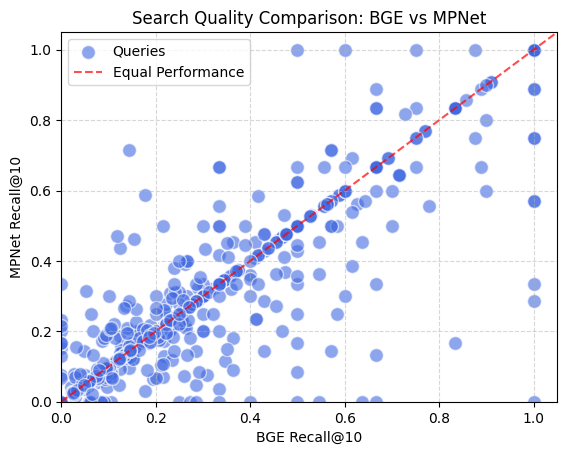

In [51]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.scatter(
    comparison['recall_bge'], 
    comparison['recall_mpnet'], 
    alpha=0.6, 
    color='royalblue', 
    edgecolors='white', 
    s=100,
    label='Queries'
)

# Add a diagonal line (y=x) for reference
# If a point is above the line, MPNet is better. If below, BGE is better.
line_coords = [0, 1.05] 
plt.plot(line_coords, line_coords, color='red', linestyle='--', alpha=0.7, label='Equal Performance')

# Formatting the plot
plt.xlabel('BGE Recall@10')
plt.ylabel('MPNet Recall@10')
plt.title('Search Quality Comparison: BGE vs MPNet')
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Save the result
plt.savefig('recall_comparison_scatter.png')

---

## Task 6: Git Submission (5 points)

Submit your work using the Git workflow:

- [ ] Create a new branch called `homework-4`
- [ ] Commit your work with a meaningful message
- [ ] Push to GitHub
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

The TA will verify your submission by checking the merged PR on GitHub.